In [ ]:
#@title Imports
import torch, torch.nn as nn, torch.nn.functional as F, torchvision
from torch.utils.data import Subset, DataLoader
from torchvision import transforms, datasets, models
import numpy as np, matplotlib.pyplot as plt

In [ ]:
#@title Device
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [ ]:
#@title Variables
BATCH_SIZE = 12
ATTENTION_HEADS = 4
TRANSFORMER_LAYERS = 4
EMBED_DIM = 16
IMG_SIZE = 28
PATCH_SIZE = 7
CLASSES = 10
EPOCHS_STUDENT = 10
LR_STUDENT = 1e-4
TEMPERATURE = 4
ALPHA = 0.1
CHANNELS = 3

In [ ]:
#@title Data
tfm = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda t: t.repeat(3,1,1)),
])
train_full = datasets.MNIST('./data', train=True, download=True, transform=tfm)
test = datasets.MNIST('./data', train=False, download=True, transform=tfm)

n = int(0.1 * len(train_full))
subset_idx = np.random.permutation(len(train_full))[:n]
train = Subset(train_full, subset_idx)

train_dl = DataLoader(train, batch_size=BATCH_SIZE, shuffle=True)
test_dl = DataLoader(test, batch_size=BATCH_SIZE)

In [ ]:
teacher = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
teacher.fc = nn.Linear(teacher.fc.in_features, CLASSES)
teacher.to(device)

# Freeze all layers except the classification layer
for param in teacher.parameters():
    param.requires_grad = False

# Unfreeze the final classification layer
for param in teacher.fc.parameters():
    param.requires_grad = True

In [ ]:
#@title Student ViT
class PatchEmbed(nn.Module):
    def __init__(self, img_size=IMG_SIZE, patch=PATCH_SIZE, dim=EMBED_DIM, channels = CHANNELS):
        super().__init__()
        self.proj=nn.Conv2d(CHANNELS,dim,patch,patch)
        self.n=(img_size//patch)**2
    def forward(self,x):
        x=self.proj(x).flatten(2).transpose(1,2)
        return x

class ViT(nn.Module):
    def __init__(self,num_classes=CLASSES,dim=EMBED_DIM,depth=TRANSFORMER_LAYERS,heads=ATTENTION_HEADS):
        super().__init__()
        self.patch=PatchEmbed()
        n=self.patch.n
        self.cls=nn.Parameter(torch.zeros(1,1,dim))
        self.distill=nn.Parameter(torch.zeros(1,1,dim))
        self.pos=nn.Parameter(torch.zeros(1,n+2,dim))
        self.blocks = nn.Sequential(*[
            nn.TransformerEncoderLayer(dim, heads, dim*4, batch_first=True)
            for _ in range(depth)
        ])
        self.norm=nn.LayerNorm(dim)
        self.head_cls=nn.Linear(dim,num_classes)
        self.head_dist=nn.Linear(dim,num_classes)

    def forward(self,x):
        B=x.size(0)
        x=self.patch(x)
        cls=self.cls.expand(B,-1,-1)
        dist=self.distill.expand(B,-1,-1)
        x=torch.cat([cls,x,dist],1)+self.pos
        x = self.blocks(x)
        x=self.norm(x)
        cls_out=x[:,0]; dist_out=x[:,-1]
        cls_logits=self.head_cls(cls_out)
        dist_logits=self.head_dist(dist_out)
        return cls_logits, dist_logits

student=ViT().to(device)
opt_s=torch.optim.AdamW(student.parameters(),lr=LR_STUDENT)

In [ ]:
#@title Train Student with Hard Distillation
def kd_loss(s_logits, t_logits, y, T=TEMPERATURE, alpha = ALPHA):
    kd = F.kl_div(F.softmax(s_logits/T,dim=1),
                  F.softmax(t_logits/T,dim=1),
                  reduction='batchmean') * (T*T)
    ce = F.cross_entropy(s_logits, y)
    return alpha*kd + (1-alpha)*ce

print("Training student...")
for e in range(EPOCHS_STUDENT):
    student.train()
    for x,y in train_dl:
        x,y=x.to(device),y.to(device)
        with torch.no_grad(): t_logits=teacher(x)
        cls_logits,dist_logits=student(x)
        loss=kd_loss(dist_logits,t_logits,y)
        opt_s.zero_grad(); loss.backward(); opt_s.step()
    print(f"Epoch {e+1} done")

Training student...
Epoch 1 done
Epoch 2 done
Epoch 3 done
Epoch 4 done
Epoch 5 done
Epoch 6 done
Epoch 7 done
Epoch 8 done
Epoch 9 done
Epoch 10 done


In [ ]:
#@title Evaluate & Show Samples
student.eval()
correct=0; total=0
samples=[]
with torch.no_grad():
    for x,y in test_dl:
        x,y=x.to(device),y.to(device)
        cls_logits,dist_logits=student(x)
        cls_dist = (cls_logits+dist_logits)/2
        pred=cls_dist.argmax(1)
        correct+=(pred==y).sum().item(); total+=y.size(0)
        if len(samples)<15:
            samples.append((x.cpu(),pred.cpu(),y.cpu()))
acc=100*correct/total
print(f"Test Accuracy: {acc:.2f}%")

Test Accuracy: 54.30%


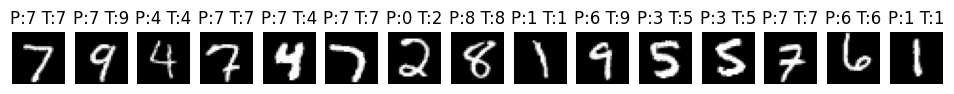

In [ ]:
#@title Display predictions
fig,axs=plt.subplots(1,len(samples),figsize=(12,3))
for i,(img,pred,true) in enumerate(samples):
    img=(img[0].permute(1,2,0).numpy())
    axs[i].imshow(img)
    axs[i].set_title(f"P:{pred[0].item()} T:{true[0].item()}")
    axs[i].axis('off')
plt.show()